In [68]:
import math

def euclidean_distance(a: tuple, b: tuple) -> float:
    """Function that computes the euclidean distance between
        2 points given as coordinates

    Args:
        a (tuple): (a.x, a.y)
        b (tuple): (b.x, b.y)

    Returns:
        float: the distance
    """
    return math.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)

def tour_length(tour, dist ):
    """Function that computes the tour length based on some precomputed weights

    Args:
        tour (_type_): The tour beeing testes
        dist (_type_): The precomputed distances

    Returns:
        length (float) : The result
    """
    n = len(tour)
    return sum(dist[tour[i]][tour[(i + 1) % n]] for i in range(n))

In [69]:
import math
import random

def load_tsp(filename: str) -> list:
    """Function that loads data from the .tsp files based on the formatation prerequisites

    Args:
        filename (str): _description_

    Returns:
        list: _description_
    """
    coords = []
    with open(filename) as f:
        for line in f:
            if line.strip() == 'NODE_COORD_SECTION':
                break
        for line in f:
            if line.strip() == 'EOF':
                break
            parts = line.split()
            x, y = float(parts[1]), float(parts[2])
            coords.append((x, y))
            
    
    n = len(coords)
    
    dists = [[euclidean_distance(coords[i], coords[j]) 
         for j in range(n)] 
         for i in range(n)]
    
    return coords, dists

In [74]:
def greedy_tsp(coords, dists) -> tuple:
    
    # random.seed(42)
    n = len(coords)
    start = random.randint(0, n - 1)

    tour = [start]
    available = set(range(n))
    available.remove(start)
    current = start

    while available:
        nearest = None
        nearest_dist = float('inf')

        for node in available:
            dist = dists[current][node]  
            if dist < nearest_dist:
                nearest_dist = dist
                nearest = node

        tour.append(nearest)
        available.remove(nearest)
        current = nearest

    length = tour_length(tour, dists)
    return tour, length

In [100]:
from collections import deque

def tabu_for_tsp(filename: str, iterations: int, max_tries: int = 4, sample_size: int = 100):
    """ Tabu search implemnted specifically for the tsp problem.
    We use the 2-opt neighbour and for better efficieny we have a sample size for the amount of
    neighbour distances checked.

    Args:
        filename (str): input file
        iterations (int): number of iterations over the finding best neighbiur
        max_tries (int, optional): number of tries we restart from random tour or random greedy
        sample_size (int, optional): number of neighbour distances beeing checked for efficiency

    Returns:
        best_length (float) : The final result for the TSP
    """
    
    coords, dists = load_tsp(filename)
    n = len(coords)
    tabu_tenure = 3*n

    global_best = None
    global_best_length = float('inf')
    try :
        for try_ in range(max_tries):

            c, length = greedy_tsp(coords, dists)
            
            # print(f"For try_{try_} :")
            # print(f"Starting from : {length}")
            
            # c = list(range(n))
            # random.shuffle(c)
            # length = tour_length(c, dists)      
            
            best = c.copy()
            best_length = length

            M = deque(maxlen=tabu_tenure)

            for iteration in range(iterations):
                x, x_length, x_move = None, float('inf'), (-1, -1)

                T = set()
                while len(T) < sample_size:
                    i = random.randint(0, n - 2)
                    j = random.randint(i + 1, n - 1)
                    T.add((i, j))

                for i, j in T:
                    neighbor = c.copy()
                    neighbor[i:j+1] = neighbor[i:j+1][::-1]
                    neighbor_length = tour_length(neighbor, dists)

                    is_tabu = (i, j) in M or (j, i) in M

                    if not is_tabu or neighbor_length < best_length:
                        if neighbor_length < x_length:
                            x, x_length, x_move = neighbor.copy(), neighbor_length, (i, j)

                if x is None:
                    continue

                M.append(x_move)
                c = x

                if x_length < best_length:
                    best = x.copy()
                    best_length = x_length

            if best_length < global_best_length:
                global_best = best.copy()
                global_best_length = best_length
                
            # print(f"Got to {best_length}")
                
        return global_best_length
    except KeyboardInterrupt :
        print("Interupted from keyboard.\n")
    return best_length

In [90]:
# 26051. for Rwanda
# 7542 for Berlin
print(tabu_for_tsp('../Lab3Assigment3/berlin52.tsp', iterations=500, sample_size=1000))

7544.36590190409


In [101]:
print(tabu_for_tsp('../Lab3Assigment3/rw1621.tsp', iterations=100, max_tries = 4, sample_size=2000))


Interupted from keyboard.

33052.98180735768


In [83]:
import matplotlib.pyplot as plt

def generate_report(filename: str, output: str, iterations_values: list, sample_values: list):
    """We do a dedicated report function where we check how results vary in terms and relation
    to the sample size and the nr of iterations where max_tries is 4 by default

    Args:
        filename (str): _description_
        output (str): _description_
        iterations_values (list): _description_
        sample_values (list): _description_
    """
    

    results_iter = []
    results_sample = []

    with open(output, 'a') as f:
        f.write(f"\nReport for {filename}\n")

    
    with open(output, 'a') as f:
        f.write(f"\nChecking vor change in result compared to change in iteration nr\n")
    for val in iterations_values:
        result = tabu_for_tsp(filename, iterations=val, max_tries=4, sample_size=sample_values[0])
        results_iter.append(result)
        with open(output, 'a') as f:
            f.write(f"iterations={val}, max_tries=4, sample_size={sample_values[0]}, result={result}\n")

    with open(output, 'a') as f:
        f.write(f"\nChecking for change in result compared to change in sample_size\n")
    for val in sample_values:
        result = tabu_for_tsp(filename, iterations=iterations_values[0], max_tries=4, sample_size=val)
        results_sample.append(result)
        with open(output, 'a') as f:
            f.write(f"iterations={iterations_values[0]}, max_tries=4, sample_size={val}, result={result}\n")

    fig, axes = plt.subplots(1, 2)

    axes[0].plot(iterations_values, results_iter, marker='o')
    axes[0].set_title("Iterations vs best tour")
    axes[0].set_xlabel("Iterations")
    axes[0].set_ylabel("Best tour length")
    axes[0].grid(True)

    axes[1].plot(sample_values, results_sample, marker='o')
    axes[1].set_title("Sample size vs best tour")
    axes[1].set_xlabel("Sample size")
    axes[1].set_ylabel("Best tour length")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


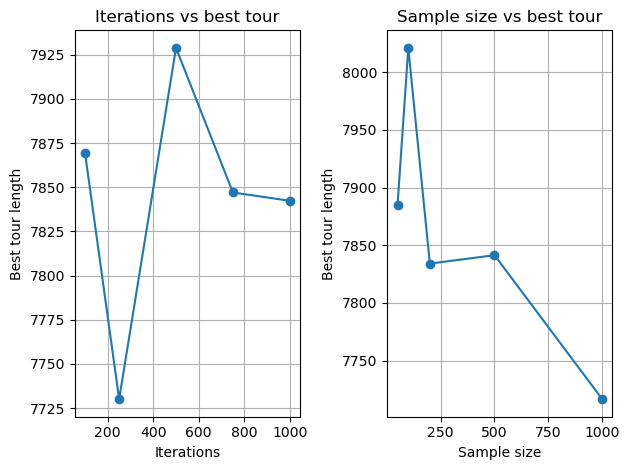

In [84]:
# Here is for greedy start for berlin52
generate_report('../Lab3Assigment3/berlin52.tsp', 'report_berlin52.txt',
                iterations_values=[100, 250, 500, 750, 1000],
                sample_values=[50, 100, 200, 500, 1000])

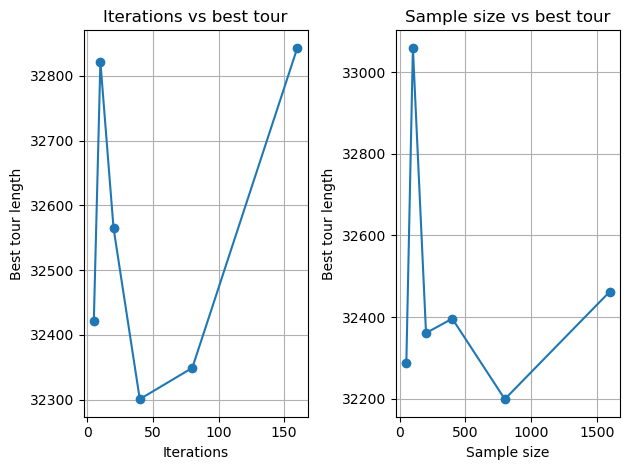

In [89]:
# Report generated for rw1621
generate_report('../Lab3Assigment3/rw1621.tsp', 'report_rw1621.txt',
                iterations_values=[5, 10, 20, 40, 80, 160],
                sample_values=[50, 100, 200, 400, 800, 1600])